In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kmader_skin_cancer_mnist_ham10000_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

print('Data source import complete.')


Data source import complete.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time
import tensorflow as tf # Imports tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization,Embedding
from tensorflow.keras.layers import Conv2D, MaxPooling2D, ReLU, LSTM,Bidirectional,Attention,Concatenate
from tensorflow.keras import regularizers, optimizers,losses
from tensorflow.keras.metrics import Accuracy,Recall,Precision,AUC,TruePositives,TrueNegatives,FalseNegatives,FalsePositives, SpecificityAtSensitivity,SensitivityAtSpecificity
from tensorflow.keras import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.python.keras.utils import np_utils
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
import sklearn.metrics as m
from glob import glob
import skimage.io
import skimage.color
import skimage.filters
from tensorflow.keras.applications import VGG19

In [ ]:
data = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv', engine='python')
# data.head()

In [ ]:
# data.columns

In [ ]:
data.isnull().any().sum()

np.int64(0)

In [ ]:
y = data['label']
x = data.drop(columns = ['label'])

In [ ]:
# Membaca data dari file CSV
tabular_data = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# Mapping nilai kolom 'dx' sesuai dengan dictionary dx
dx_mapping = {
    'nv': 'nv',
    'mel': 'mel',
    'bkl': 'bkl',
    'bcc': 'bcc',
    'vasc': 'vasc',
    'akiec': 'akiec',
    'df': 'df'
}

# Mengubah nilai kolom 'dx' menggunakan mapping
tabular_data['dx'] = tabular_data['dx'].map(dx_mapping)

# # Menampilkan 5 baris pertama untuk memastikan perubahan
# tabular_data.head()

Processing images in /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1: 100%|██████████| 5000/5000 [00:50<00:00, 99.36it/s] 
Processing images in /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2: 100%|██████████| 5015/5015 [00:50<00:00, 99.20it/s] 


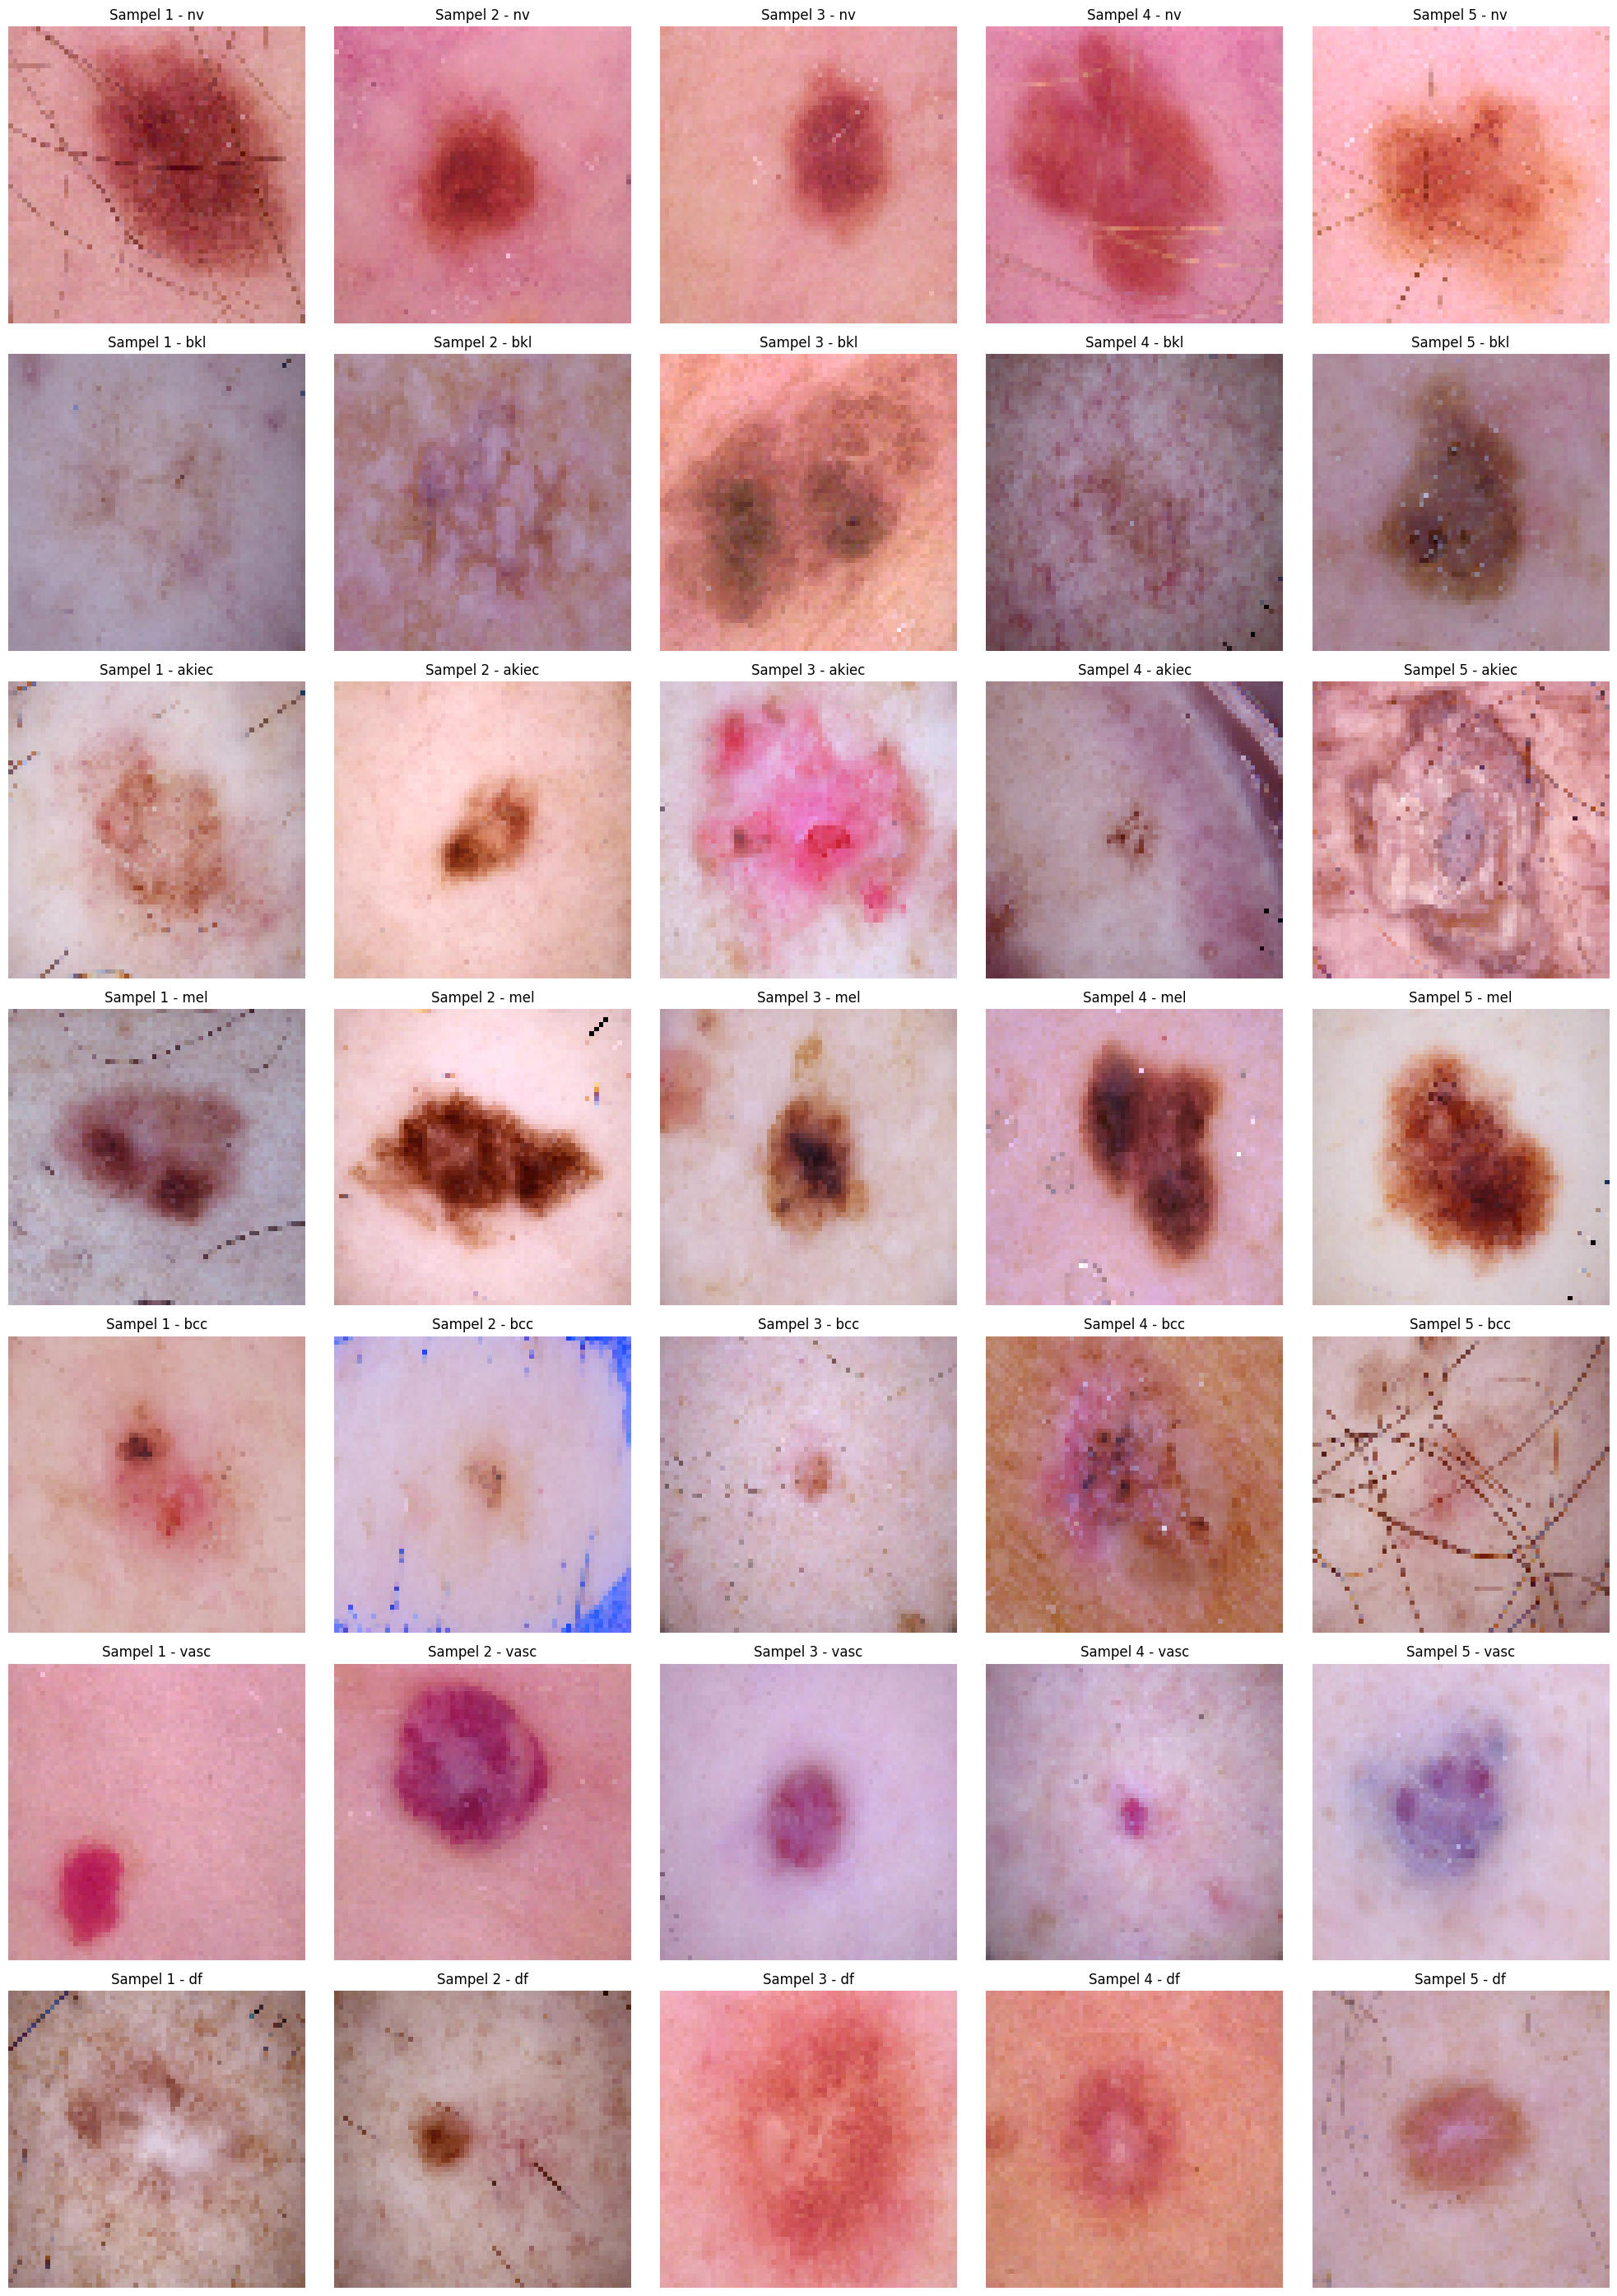

In [ ]:
from tensorflow.keras.utils import img_to_array

image_folders = [
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

# Mengumpulkan gambar dalam masing-masing folder dan menyesuaikan dengan label nya
# Membuat dictionary untuk memetakan image_id ke label
label_mapping = dict(zip(tabular_data['image_id'], tabular_data['dx']))

# Buat list untuk menyimpan data gambar dan label
image_data = []
labels = []

# Buat variable untuk menyimpan gambar pertama setelah di resize menjadi 64x64
first_image_array = None
first_image_found = False

# Fungsi untuk resize gambar
def resize_image(img_path, target_size=(64, 64)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = img_to_array(img)
    return img_array
# Fungsi untuk transformasi gambar (split channel dan flatten)
def transform_image(img_array):
    R = img_array[:, :, 0].flatten()
    G = img_array[:, :, 1].flatten()
    B = img_array[:, :, 2].flatten()
    reordered_array = np.concatenate([R, G, B])
    return reordered_array

import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# Inisialisasi awal
image_data = []
labels = []
class_images = {}  # Dictionary untuk menyimpan beberapa gambar per kelas (maks. 3 per kelas)

for folder in image_folders:
    image_files = [f for f in os.listdir(folder) if f.endswith('.jpg')]

    for image_file in tqdm(image_files, desc=f"Processing images in {folder}"):
        img_path = os.path.join(folder, image_file)

        # --- Resize gambar ---
        img_array = resize_image(img_path)

        # --- Ambil ID gambar dan Label ---
        image_id = os.path.splitext(image_file)[0]
        label = label_mapping.get(image_id)

        if label is not None:
            # --- Simpan sampai 5 gambar per kelas ---
            if label not in class_images:
                class_images[label] = []

            if len(class_images[label]) < 5:
                class_images[label].append(img_array.copy())

            # --- Transformasi gambar ---
            transformed_array = transform_image(img_array)

            # --- Simpan hasil ---
            image_data.append(transformed_array)
            labels.append(label)

# Visualisasi: Tampilkan 3 gambar per kelas
num_classes = len(class_images)
samples_per_class = 5
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(4 * samples_per_class, 4 * num_classes))

# Tangani kasus ketika hanya ada 1 kelas
if num_classes == 1:
    axes = [axes]

for row_idx, (label, images) in enumerate(class_images.items()):
    for col_idx in range(samples_per_class):
        if num_classes > 1:
            ax = axes[row_idx][col_idx]
        else:
            ax = axes[col_idx]

        if col_idx < len(images):
            ax.imshow(images[col_idx].astype('uint8'))
            ax.set_title(f"Sampel {col_idx+1} - {label}")
        else:
            ax.axis("off")
        ax.axis("off")

plt.tight_layout()
plt.show()


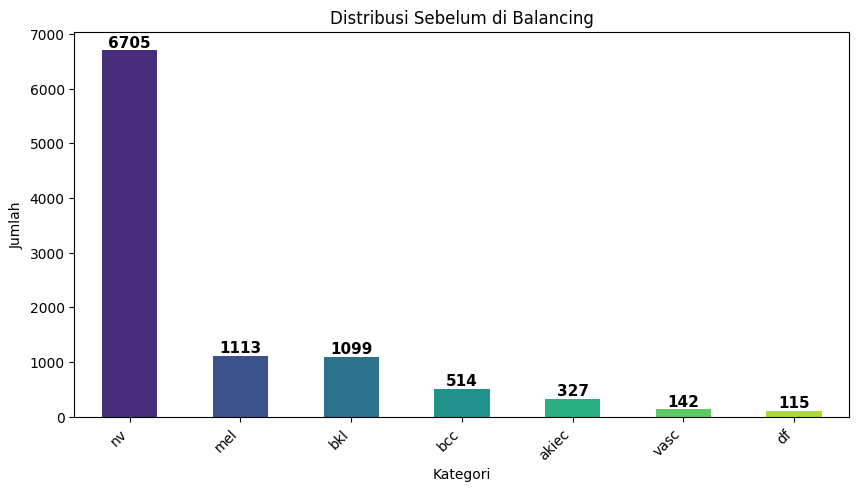

In [ ]:
# Membuat figure dan axes
fig, ax1 = plt.subplots(1, 1, figsize=(10,5))

# Plot bar chart
counts = tabular_data['dx'].value_counts()

# Mendapatkan palet warna 'viridis' dari seaborn
colors = sns.color_palette('viridis', n_colors=len(counts))

# Plot dengan warna dari palet 'viridis'
counts.plot(kind='bar', ax=ax1, color=colors)

# Tambahkan judul dan label sumbu
plt.title('Distribusi Sebelum di Balancing')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.xticks(rotation=45, ha="right")

# Tambahkan nilai di atas setiap batang
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',                       # Teks jumlah
                 (p.get_x() + p.get_width() / 2., p.get_height()),  # Posisi teks
                 ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

# Tampilkan grafik
plt.show()


In [ ]:
x= np.array(x).reshape(-1,28,28,3)
print('Shape of X :',x.shape)

Shape of X : (10015, 28, 28, 3)


In [ ]:
x = tf.image.resize(x, (32, 32))
print('Shape of X after resizing:', x.shape)

Shape of X after resizing: (10015, 32, 32, 3)


In [ ]:
y = to_categorical(y)
y.shape

(10015, 7)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from collections import Counter

In [ ]:
class_labels = ['nv',
    'mel',
    'bkl',
    'bcc',
    'vasc',
    'akiec',
    'df'
]

# Konversi ke numpy array
x = np.array(x)
y = np.array(y)

# Flatten fitur untuk RandomOverSampler
x_flat = x.reshape(x.shape[0], -1)

# Oversampling sebelum split data
ros = RandomOverSampler()
x_balanced, y_balanced = ros.fit_resample(x_flat, y)

# Split data menjadi training (80%) dan testing (20%)
X_train_flat, X_test_flat, Y_train, Y_test = train_test_split(
    x_balanced, y_balanced, test_size=0.2, random_state=1
)

# Reshape kembali X_train dan X_test ke bentuk asli jika perlu
X_train = X_train_flat.reshape(-1, *x.shape[1:])
X_test = X_test_flat.reshape(-1, *x.shape[1:])

# Jika Y_train berbentuk one-hot encoding, ubah ke label integer
if Y_train.ndim > 1 and Y_train.shape[1] > 1:
    Y_train = np.argmax(Y_train, axis=1)
    Y_test = np.argmax(Y_test, axis=1)

# Hitung jumlah sampel dalam setiap kelas
train_counts = Counter(Y_train)
test_counts = Counter(Y_test)


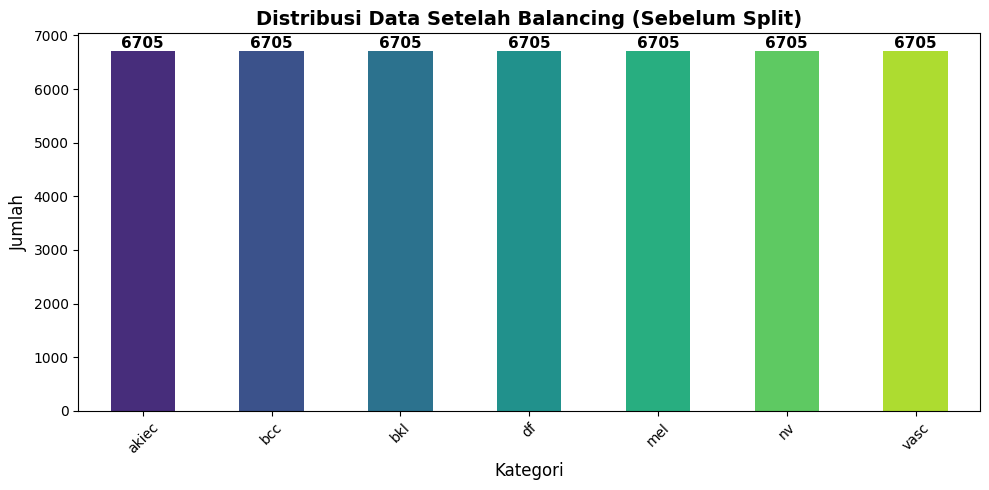

In [ ]:
# Ubah one-hot ke label angka
if y_balanced.ndim > 1 and y_balanced.shape[1] > 1:
    y_balanced = np.argmax(y_balanced, axis=1)

# Mapping label angka ke nama label
label_series = pd.Series(y_balanced).map(dict(enumerate(class_labels)))

# Buat DataFrame dan hitung jumlah tiap label
train_balanced_df = pd.DataFrame({'Label': label_series})
train_balanced_counts = train_balanced_df['Label'].value_counts().sort_index()

# Plot
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
colors = sns.color_palette('viridis', n_colors=len(train_balanced_counts))

train_balanced_counts.plot(kind='bar', ax=ax1, color=colors)

plt.title('Distribusi Data Setelah Balancing (Sebelum Split)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45)

# Tambahkan label jumlah di atas batang
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

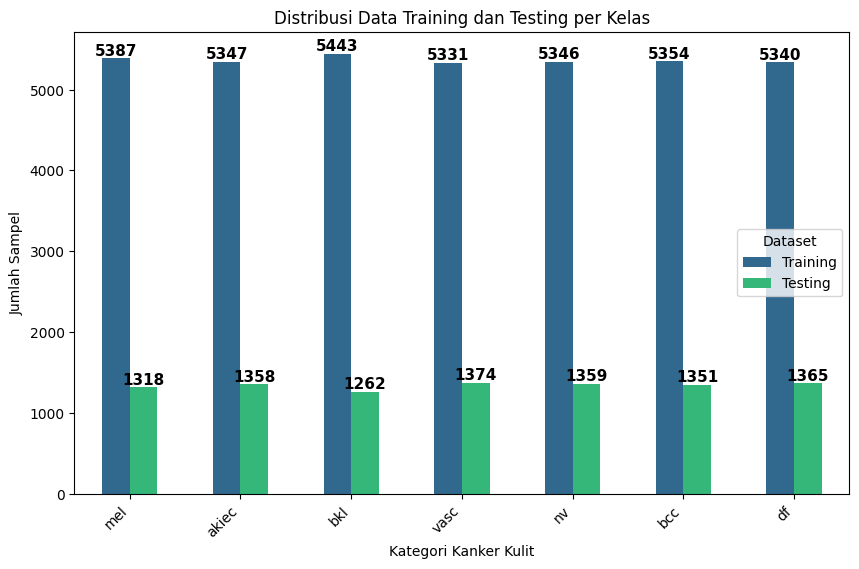

In [ ]:
# Buat dataframe untuk visualisasi
df_counts = pd.DataFrame({
    "Kategori": [class_labels[k] for k in train_counts.keys()],
    "Training": list(train_counts.values()),
    "Testing": [test_counts[k] if k in test_counts else 0 for k in train_counts.keys()]
})

# Plot distribusi data training dan testing
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", n_colors=2)
df_counts.set_index("Kategori").plot(kind="bar", ax=ax, color=colors)

plt.title("Distribusi Data Training dan Testing per Kelas")
plt.xlabel("Kategori Kanker Kulit")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")

# Label di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')
plt.show()

In [ ]:
# Split data training menjadi training (80%) dan validasi (20%) dari data training awal
X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=1
)

# Cek bentuk data
print("Training set:", X_train_final.shape, Y_train_final.shape)
print("Validation set:", X_val.shape, Y_val.shape)
print("Testing set:", X_test.shape, Y_test.shape)

Training set: (30038, 32, 32, 3) (30038,)
Validation set: (7510, 32, 32, 3) (7510,)
Testing set: (9387, 32, 32, 3) (9387,)


In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import Recall, Precision, AUC, TruePositives, TrueNegatives, FalseNegatives, FalsePositives
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

# Define input shape
img_shape = (32, 32, 3)

# Function to build the model
def build_model():
    # Load pretrained VGG19 without fully connected layers
    base_model = VGG19(
        include_top=False,
        input_shape=img_shape,
        weights="imagenet"  # Use pretrained ImageNet weights
    )

    # Fine-tuning setup (unfreeze all layers)
    for layer in base_model.layers[:6]:
        layer.trainable = False

    # Menampilkan struktur model VGG19
    print("\n=== VGG19 Base Model Summary ===")
    base_model.summary()

    # Build the model
    model = Sequential([
        base_model,
        Flatten(),
        BatchNormalization(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(7, activation='softmax')  # Output layer for 7 classes
    ])

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),  # Lower LR for fine-tuning
        loss=CategoricalCrossentropy(),
        metrics=[
            'accuracy',
            Recall(name='recall'),
            Precision(name='precision'),
            # AUC(name='auc'),
            # TruePositives(name='true_positives'),
            # TrueNegatives(name='true_negatives'),
            # FalseNegatives(name='false_negatives'),
            # FalsePositives(name='false_positives')
        ]
    )
    return model

# Enable GPU acceleration if available
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Build the model
model = build_model()

# Print model summary
model.summary()


TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== VGG19 Base Model Summary ===


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 19,764,224 (75.39 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     2,101,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │        28,679 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,937,671 (148.54 MB)

 Trainable params: 38,676,487 (147.54 MB)

 Non-trainable params: 261,184 (1020.25 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
import numpy as np
from sklearn.model_selection import train_test_split

# Pastikan X_train dan Y_train dari proses balancing sebelumnya
X_train = np.array(X_train)
Y_train = np.array(Y_train, dtype=int)  # label dalam bentuk integer

# Split data menjadi train dan validation (80% train, 20% validasi)
X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train, Y_train, test_size=0.2, random_state=1, stratify=Y_train
)

# One-hot encoding untuk label
num_classes = 7
Y_train_final_cat = to_categorical(Y_train_final, num_classes=num_classes)
Y_val_cat = to_categorical(Y_val, num_classes=num_classes)

# Build model
model = build_model()

# Callback untuk menyimpan model terbaik (berdasarkan val_loss)
checkpoint = ModelCheckpoint(
    filepath='best_vgg19.keras',
    monitor='val_loss',        # 👉 Lebih stabil untuk generalisasi
    mode='min',
    verbose=1,
    save_best_only=True
)

# Callback untuk early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',        # 👉 Lebih aman terhadap overfitting
    mode='min',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_final, Y_train_final_cat,
    validation_data=(X_val, Y_val_cat),
    epochs=100,
    batch_size=50,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

print("Training complete!")



=== VGG19 Base Model Summary ===


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 19,764,224 (75.39 MB)

 Non-trainable params: 260,160 (1016.25 KB)

Epoch 1/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2760 - loss: 1.7826 - precision: 0.5524 - recall: 0.0969
Epoch 1: val_loss improved from inf to 1.62385, saving model to best_vgg19.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 69s 93ms/step - accuracy: 0.2762 - loss: 1.7823 - precision: 0.5527 - recall: 0.0970 - val_accuracy: 0.3557 - val_loss: 1.6238 - val_precision: 0.5338 - val_recall: 0.1672
Epoch 2/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4099 - loss: 1.3805 - precision: 0.6765 - recall: 0.1852
Epoch 2: val_loss improved from 1.62385 to 1.13996, saving model to best_vgg19.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.4099 - loss: 1.3804 - precision: 0.6766 - recall: 0.1852 - val_accuracy: 0.5160 - val_loss: 1.1400 - val_precision: 0.8641 - val_recall: 0.2422
Epoch 3/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4904 - loss: 1.2103 - precision: 0.7329 - recall: 0.2650
Epoch 3: val_loss improved from 1.13996 to 1.00349, savin

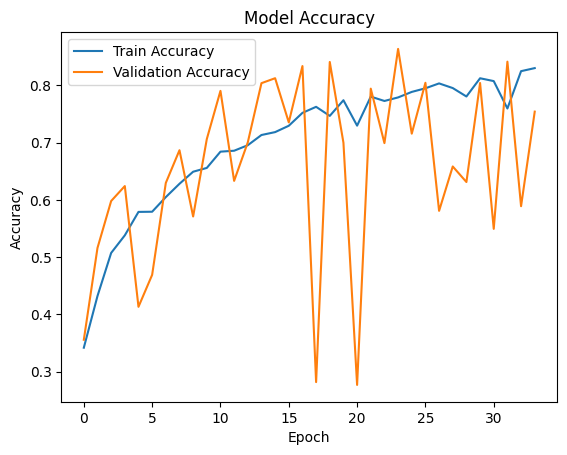

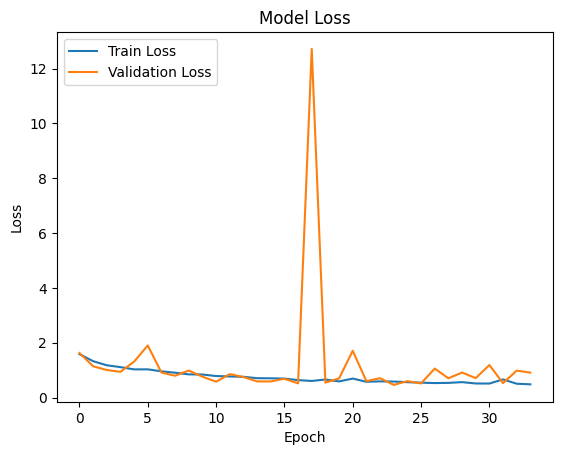

In [ ]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [ ]:
# Summary Training (Non K-Fold)

print("Training Summary:")

# Loss terendah
best_train_loss = min(history.history['loss'])
best_loss_epoch = history.history['loss'].index(best_train_loss) + 1
print(f"  Lowest Training Loss    : {best_train_loss:.4f} at Epoch {best_loss_epoch}")

# Akurasi terbaik
best_train_acc = max(history.history['accuracy'])
best_acc_epoch = history.history['accuracy'].index(best_train_acc) + 1
print(f"  Best Training Accuracy  : {best_train_acc:.4f} at Epoch {best_acc_epoch}")

# Precision (jika tersedia)
if 'precision' in history.history:
    best_precision = max(history.history['precision'])
    best_precision_epoch = history.history['precision'].index(best_precision) + 1
    print(f"  Best Training Precision : {best_precision:.4f} at Epoch {best_precision_epoch}")

# Recall (jika tersedia)
if 'recall' in history.history:
    best_recall = max(history.history['recall'])
    best_recall_epoch = history.history['recall'].index(best_recall) + 1
    print(f"  Best Training Recall    : {best_recall:.4f} at Epoch {best_recall_epoch}")

# # AUC (jika tersedia)
# if 'auc' in history:
#     best_auc = max(history['auc'])
#     best_auc_epoch = history['auc'].index(best_auc) + 1
#     print(f"  Best Training AUC       : {best_auc:.4f} at Epoch {best_auc_epoch}")


Training Summary:
  Lowest Training Loss    : 0.4813 at Epoch 34
  Best Training Accuracy  : 0.8299 at Epoch 34
  Best Training Precision : 0.8391 at Epoch 34
  Best Training Recall    : 0.8177 at Epoch 34


In [ ]:
from tensorflow.keras.utils import to_categorical

Y_test = to_categorical(Y_test, num_classes=7)

print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_test shape: (9387, 32, 32, 3)
Y_test shape: (9387, 7)


In [ ]:
# Evaluate the model
results = model.evaluate(X_test, Y_test, verbose=1)

# Unpack the results
loss, acc, recall, precision = results[:5]  # Sesuaikan sesuai urutan metrik yang dikompilasi
print(f"Loss: {loss}")
print(f"Accuracy: {acc}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
# print(f"AUC: {auc}")


294/294 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8564 - loss: 0.4659 - precision: 0.8733 - recall: 0.8424
Loss: 0.46409398317337036
Accuracy: 0.8570363521575928
Recall: 0.8425481915473938
Precision: 0.8763434886932373


In [ ]:
# Predict labels for the test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(Y_test, axis=1)

# Calculate precision, recall, and f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='macro')
recall = recall_score(y_true_classes, y_pred_classes, average='macro')
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')

print(f"Accuracy: {accuracy}")
print(f"Macro-Precision: {precision}")
print(f"Macro-Recall: {recall}")
print(f"Macro-F1 Score: {f1}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_true_classes, y_pred_classes, target_names=class_labels))


294/294 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Accuracy: 0.8570363268349845
Macro-Precision: 0.8820559553571995
Macro-Recall: 0.8574231917802877
Macro-F1 Score: 0.8528808562058859

Classification Report:
               precision    recall  f1-score   support

          nv       0.69      0.91      0.79      1359
         mel       0.98      0.63      0.77      1318
         bkl       0.79      0.94      0.86      1262
         bcc       0.99      1.00      1.00      1351
        vasc       0.96      0.58      0.73      1374
       akiec       1.00      0.99      1.00      1358
          df       0.75      0.95      0.84      1365

    accuracy                           0.86      9387
   macro avg       0.88      0.86      0.85      9387
weighted avg       0.88      0.86      0.85      9387



Confusion matrix, without normalization


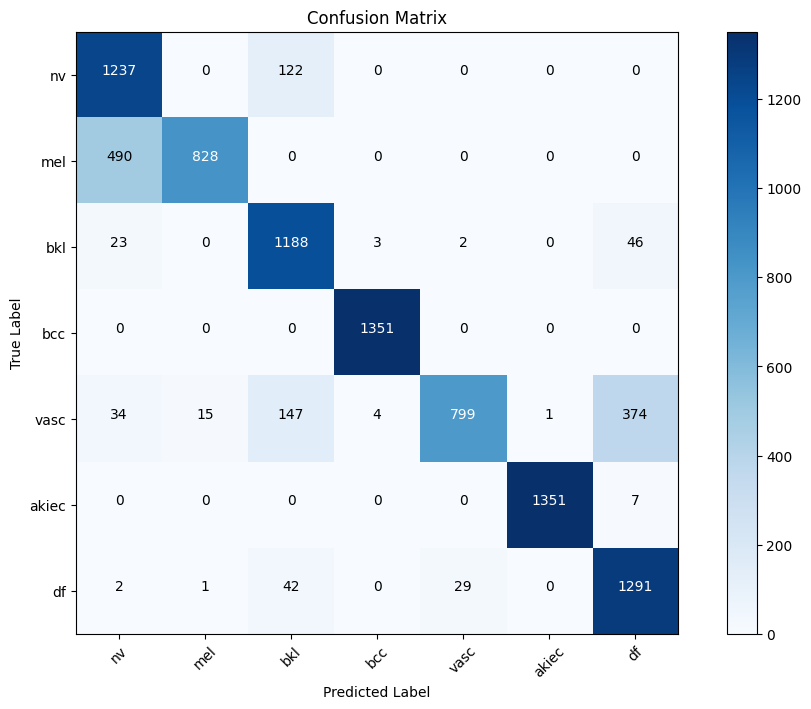

In [ ]:
from sklearn.metrics import confusion_matrix
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize=(10, 7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]:.2f}" if normalize else f"{cm[i, j]}",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Compute confusion matrix
confusion_mtx = confusion_matrix(y_true_classes, y_pred_classes)

# Define class names (adjust based on your dataset)
# class_names = [f"Class {i+1}" for i in range(Y_test.shape[1])]
class_names = [
'nv',
    'mel',
    'bkl',
    'bcc',
    'vasc',
    'akiec',
    'df']

# Plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes=class_names, normalize=False, title='Confusion Matrix')
